# 00 · Quickstart — a layout to S-parameters in ten lines

The whole toolbox in one breath: take a component, pair it with a technology,
pick an engine, and get a scattering matrix back. This runs on **beamz** — the
free, open-source JAX FDTD engine — so there's no cloud account or license to
set up.

```
Component  +  Technology  +  SimulationSpec   ──get_solver(engine)──▶  SMatrix
```

The rest of the guide (`01`–`10`) unpacks each piece. This page is just proof
that it's quick.

In [1]:
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt

from gds_fdtd.layout.gdsfactory import from_gdsfactory
from gds_fdtd.plotting import plot_component, plot_smatrix
from gds_fdtd.solvers import get_solver
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)

## The ten lines

A 3 µm straight silicon waveguide, simulated 1.5–1.6 µm on beamz.

In [2]:
gf.gpdk.PDK.activate()
tech = Technology.from_yaml(_find("examples/tech.yaml"))
component = from_gdsfactory(gf.components.straight(length=3), tech)
spec = SimulationSpec(
    wavelength_start=1.5, wavelength_end=1.6, wavelength_points=5, mesh=6, z_min=-1.0, z_max=1.11
)

solver = get_solver("beamz")(component, technology=tech, spec=spec)
smatrix = solver.run()  # the only line that spends compute (free & local here)

print(f"ports {smatrix.port_names}  ·  {smatrix.f.size} wavelengths")
print(f"through |S21| peak: {float(smatrix.magnitude_db(out='o2', in_='o1').max()):+.3f} dB")

20:30:36 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

● Done: Raster cache hit (3d): 78b41468738b996da53e44784d675587621d3e9f5b8d0f4f7d8292ce9c127280.npz | load=0.10s


ports ['o1', 'o2']  ·  5 wavelengths
through |S21| peak: -0.004 dB


## What came back

The geometry (auto-detected ports + simulation region) and the S-parameters —
a straight waveguide passes ~all its power through (≈ 0 dB).

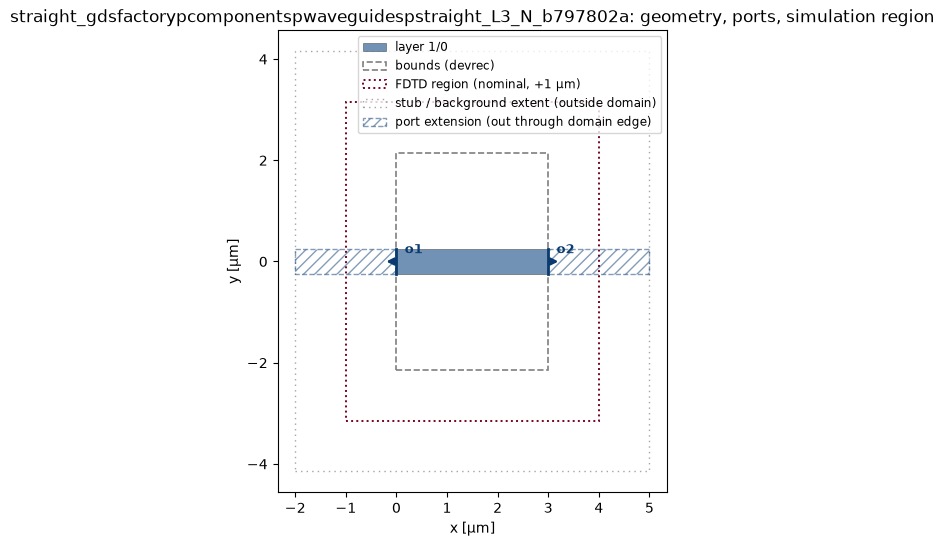

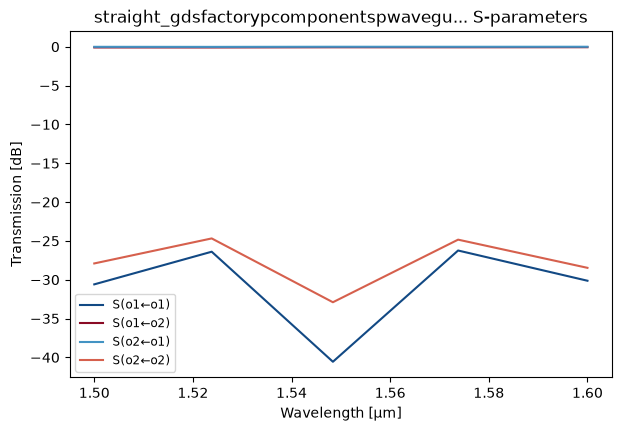

In [3]:
plot_component(component, spec)
plt.show()

plot_smatrix(smatrix, kind="db")
plt.show()

…and the run's **field profile** — |E|² in the device plane, the guided mode
carrying power left to right (every simulation example ends with this view):

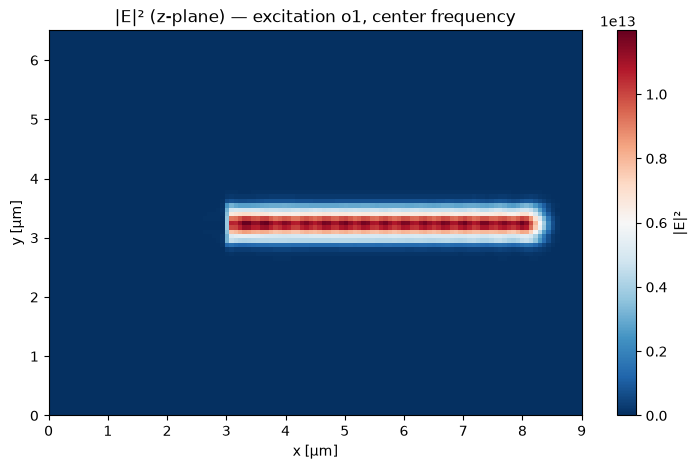

In [4]:
solver.plot_fields(axis="z")
plt.show()

## Recap & next

That's the entire contract: `Component` + `Technology` + `SimulationSpec` →
`SMatrix`. `validate()`, `build()`, and `estimate()` preview the job offline
and free before `run()` spends anything.

Next: **`01_layout_to_component`** (loading real layouts) and
**`03_first_simulation`** (the full flow, step by step).